In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, 
    cross_validate,
    RandomizedSearchCV
)
from xgboost import XGBClassifier


In [3]:
df = pd.read_csv("../data/depression_data.csv")

## The Basics

In [4]:
# Display some basic info of the df like number of rows, columns
# the dataframe head, and descriptive info of numerical columns
print(df.shape)
display(df.head())
display(df.describe().T)

(413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


,count,mean,std,min,25%,50%,75%,max
Age,413768.0,49.000713,18.158759,18.00,33.00,49.000,65.0,80.00
Number of Children,413768.0,1.298972,1.237054,0.00,0.00,1.000,2.0,4.00
Income,413768.0,50661.707971,40624.100565,0.41,21001.03,37520.135,76616.3,209995.22


A small selection of features here with only a few numerical columns. I'll be treating this as a classification problem as the "history of mental illness" that I want to predict is a yes/no column.   
The info from the kaggle site on the dataset suggested that this data was already relatively clean and deduped but worth checking for safety:

In [5]:
df.isna().sum().sort_values(ascending=False)

Name                            0
Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       0
History of Substance Abuse      0
Family History of Depression    0
Chronic Medical Conditions      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Inspect the target counts
df["History of Mental Illness"].value_counts(dropna=False)

History of Mental Illness
No     287943
Yes    125825
Name: count, dtype: int64

<Axes: xlabel='History of Mental Illness', ylabel='count'>

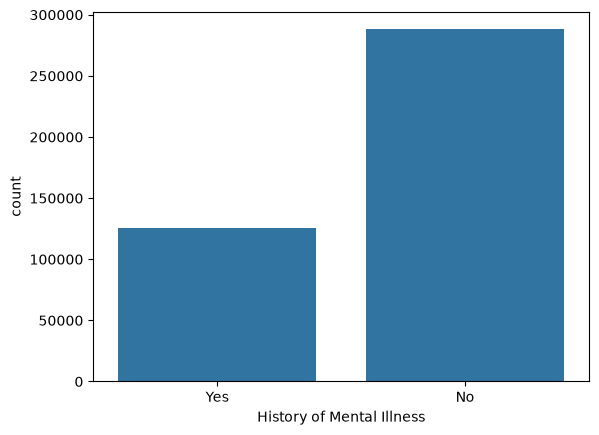

In [8]:
# Show target graphically - predominantly "no"
sns.countplot(data=df, x="History of Mental Illness")

In [9]:
# Check the proportions of yes / no in the target
df["History of Mental Illness"].value_counts(normalize=True)

History of Mental Illness
No     0.695904
Yes    0.304096
Name: proportion, dtype: float64

## Numeric Columns

In [10]:
# Select the numerical columns
numeric_cols = list(df.select_dtypes(include=np.number).columns)

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Number of Children'}>],
       [<Axes: title={'center': 'Income'}>, <Axes: >]], dtype=object)

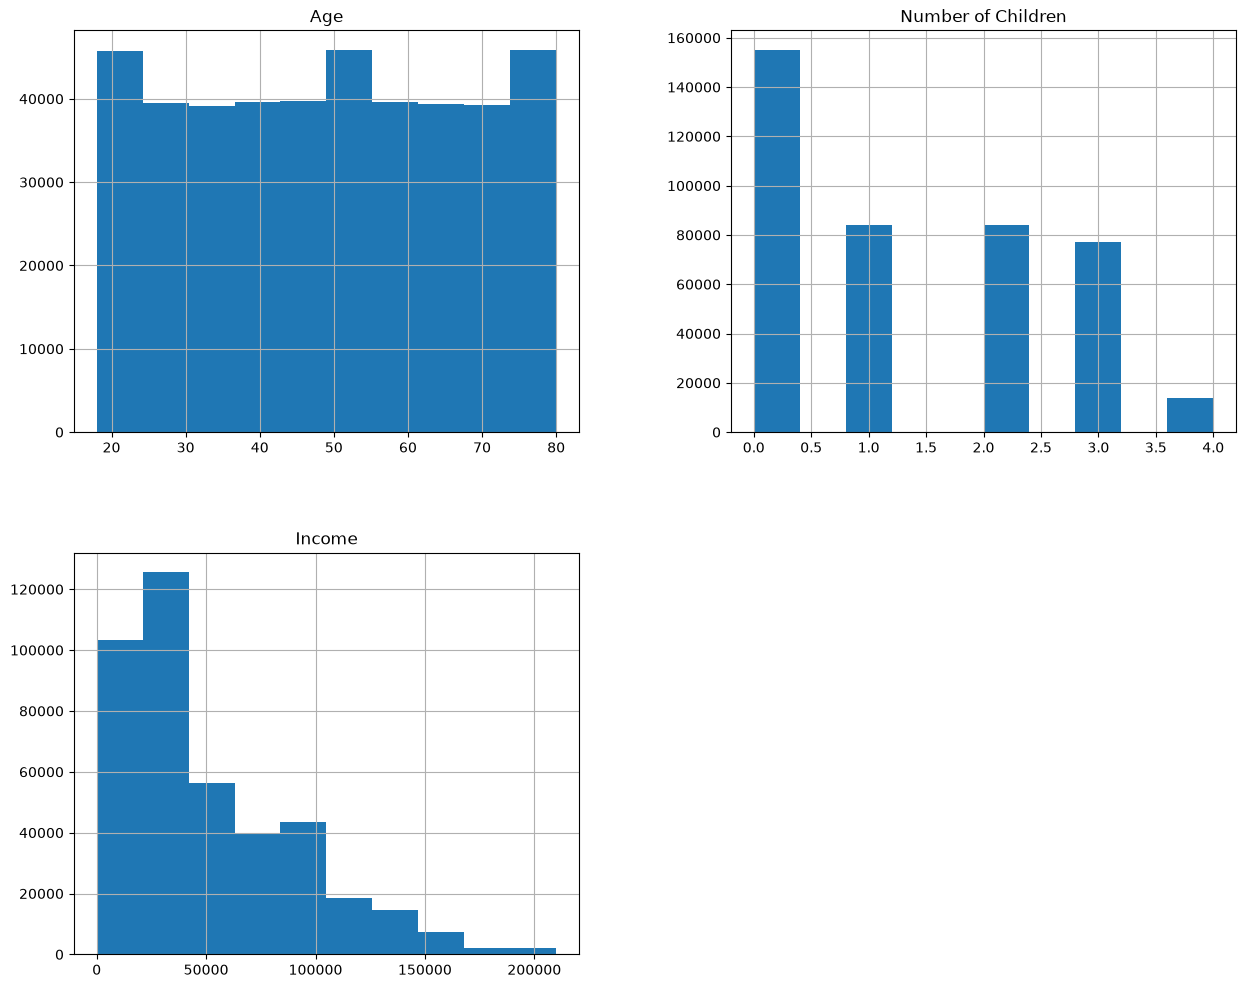

In [11]:
# Plot histograms of each of the numeric features
df[numeric_cols].hist(figsize=(15,12))

In [12]:
# Print out table of statistical values
print(
    f"{'Feature':<18} | {'Mean':<8} | "
    f"{'Median':<8} | {'Standard Deviation':<8}"
)
for column in numeric_cols:
    print(
        f"{column:<18} | {df[column].mean():<8.2f} | "
        f"{df[column].median():<8.2f} | {df[column].std():<8.2f}"
    )

Feature            | Mean     | Median   | Standard Deviation
Age                | 49.00    | 49.00    | 18.16   
Number of Children | 1.30     | 1.00     | 1.24    
Income             | 50661.71 | 37520.13 | 40624.10


##### Visually inspect numerical feature distributions

<Axes: xlabel='History of Mental Illness', ylabel='Age'>

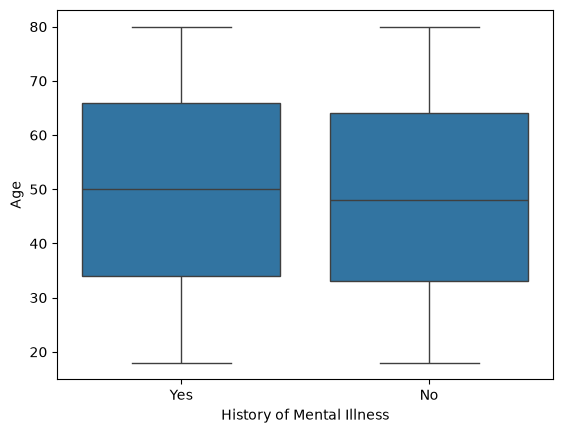

In [13]:
sns.boxplot(data=df,
            x="History of Mental Illness",
            y="Age")

<Axes: xlabel='History of Mental Illness', ylabel='Number of Children'>

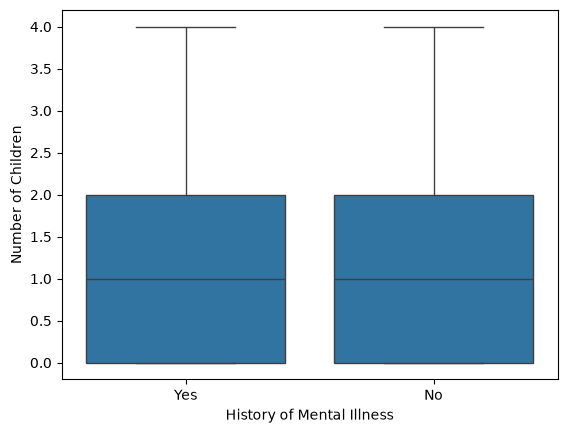

In [14]:
sns.boxplot(data=df,
            x="History of Mental Illness",
            y="Number of Children")

<Axes: xlabel='History of Mental Illness', ylabel='Income'>

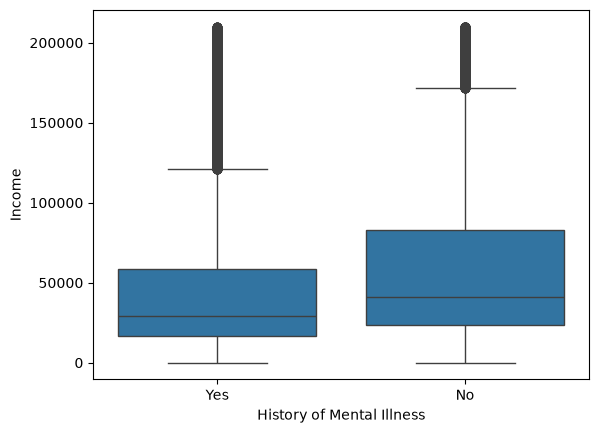

In [15]:
sns.boxplot(data=df,
            x="History of Mental Illness",
            y="Income")

Some small differences in age, very similar distributions by number of children, very different shapes when considering income. 
To me this suggests that there is some correlation with income, where higher income customers may be less likely to havea a history of mental illness.  
This is not necessarily causal (e.g. a low income job may be unlikely to result in mental illness, but those without mental illnesses may find it easier to secure a higher salary position)

## Categorical Columns

In [16]:
# Select categorical columns
categorical_cols = list(set(df.columns)-set(numeric_cols))
categorical_cols.remove("Name")
categorical_cols.remove("History of Mental Illness")

In [17]:
print(categorical_cols)

['Sleep Patterns', 'Chronic Medical Conditions', 'Employment Status', 'Smoking Status', 'Dietary Habits', 'Family History of Depression', 'Physical Activity Level', 'Marital Status', 'Alcohol Consumption', 'Education Level', 'History of Substance Abuse']


##### Visually inspect categorical feature distributions

<Axes: xlabel='History of Substance Abuse'>

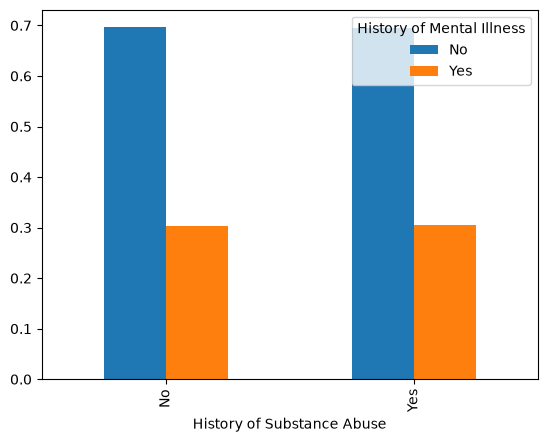

In [18]:
pd.crosstab(
    df["History of Substance Abuse"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Marital Status'>

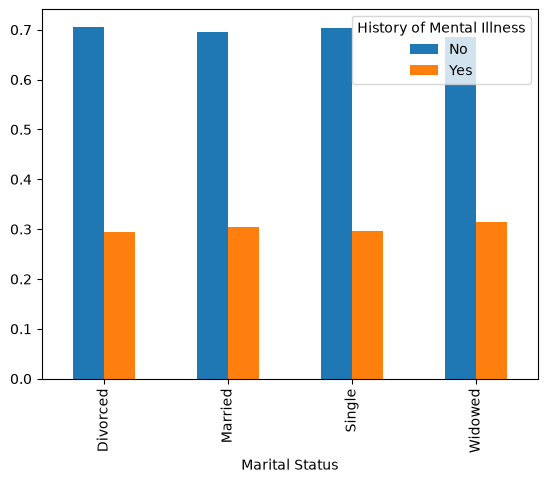

In [19]:
pd.crosstab(
    df["Marital Status"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Education Level'>

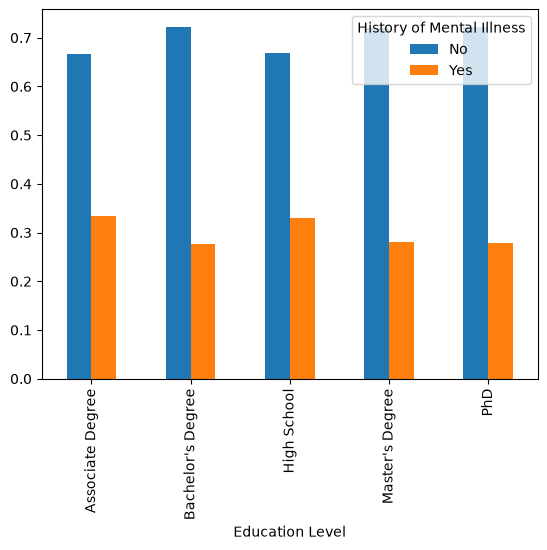

In [20]:
pd.crosstab(
    df["Education Level"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Family History of Depression'>

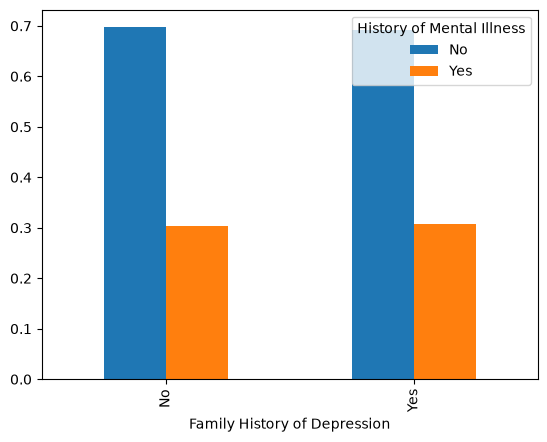

In [21]:
pd.crosstab(
    df["Family History of Depression"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Alcohol Consumption'>

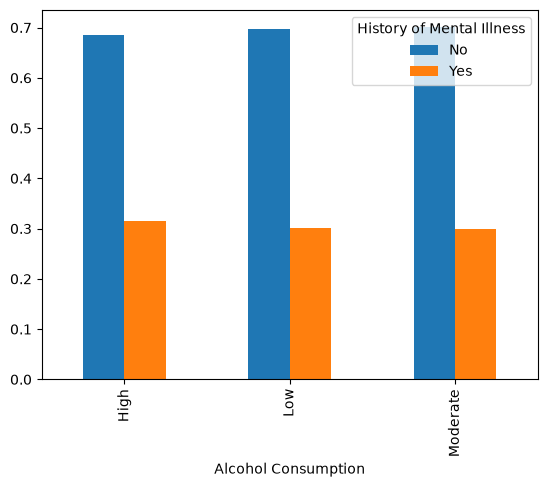

In [22]:
pd.crosstab(
    df["Alcohol Consumption"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Smoking Status'>

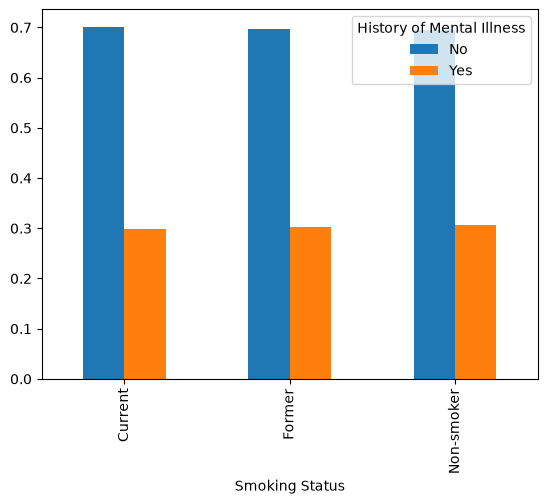

In [23]:
pd.crosstab(
    df["Smoking Status"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Physical Activity Level'>

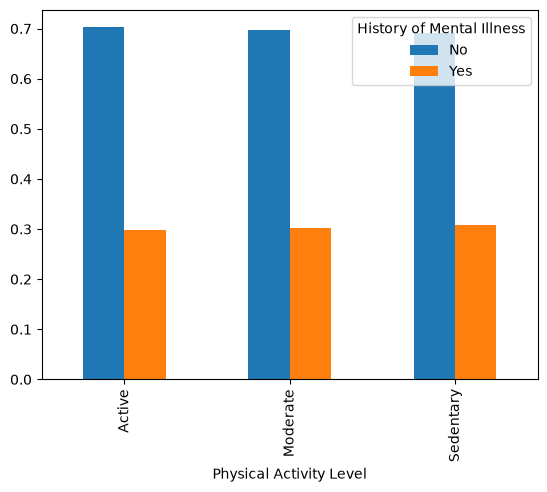

In [24]:
pd.crosstab(
    df["Physical Activity Level"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Chronic Medical Conditions'>

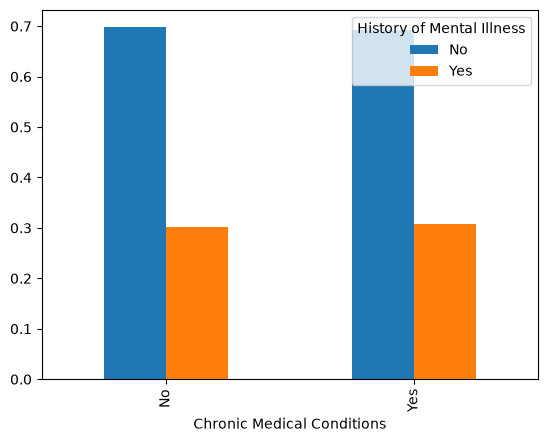

In [25]:
pd.crosstab(
    df["Chronic Medical Conditions"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Sleep Patterns'>

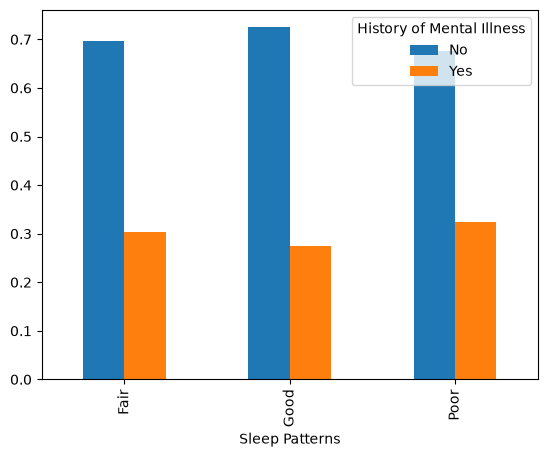

In [26]:
pd.crosstab(
    df["Sleep Patterns"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Dietary Habits'>

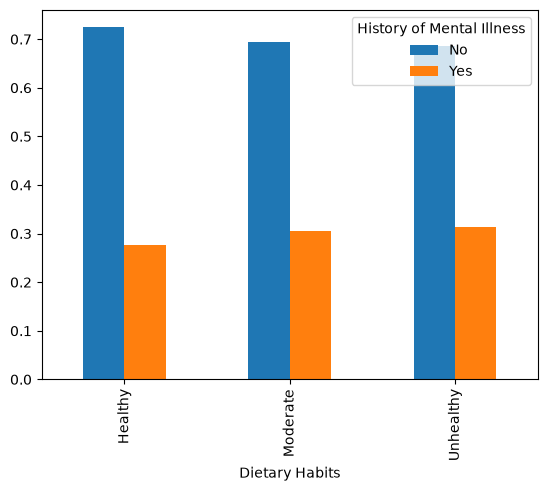

In [27]:
pd.crosstab(
    df["Dietary Habits"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

<Axes: xlabel='Employment Status'>

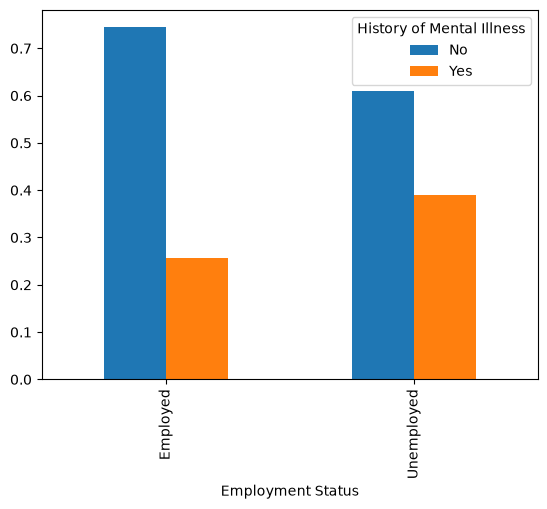

In [28]:
pd.crosstab(
    df["Employment Status"],
    df["History of Mental Illness"],
    normalize="index"
).plot(kind="bar")

These distributions suggest some small correlation between a history of mental health issues and:
 * Marital status
 * Alcohol consumption   

and larger correlation between a history of mental health issues and:
 * Sleep patterns 
 * Dietary habits
 * Employment status

## Statistical Tests

<Axes: >

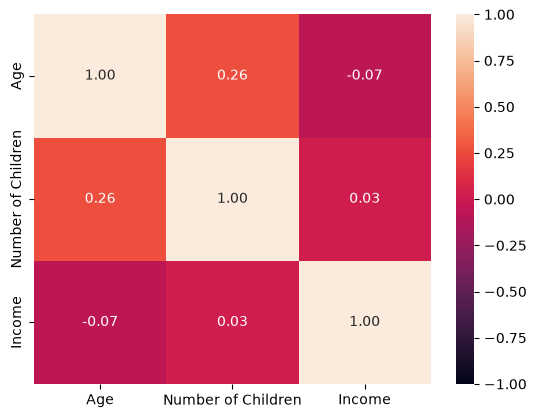

In [29]:
# We only have 3 numerical columns, but let's look at the correlation matrix
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1
)

This correlation matrix is pretty much as I would have expected it:   
 * Age and Number of Children are positively correlated, so people are more likely to have had a greater number of children as they age - this feels rational
 * Number of Children and Income are positively correlated, so people with more income are potentially better suited to support the needs of more children - this also feels rational
 * Income and Age are slightly negatively correlated, so people are likely to be lower income as they age - this was initially surprising to see

My initial expectation was that Income would increase with age, as younger people might be in education or less senior roles which I would expect to pay less. 
On refelction there are legitimate reasons for how this could be true (older people prioritising family over high career salaries, or people who have retired sitting on a lower fixed income resulting in drawing from a pension).   
Let's review the shape of the distribution to see if it fits one or both of these hypotheses. 

<Axes: xlabel='Age', ylabel='mean_income'>

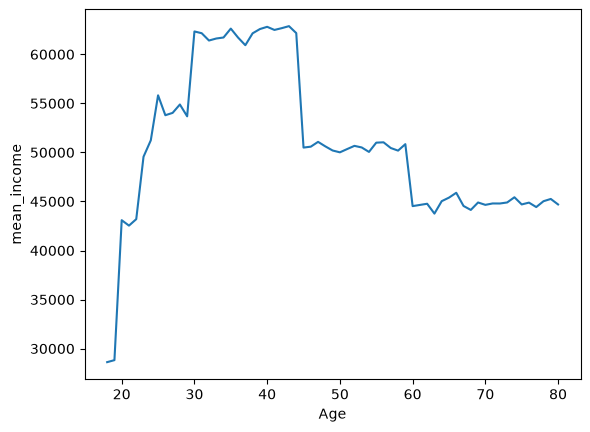

In [30]:
# Group people by their age and calculate each age's mean income
age_income_df = df.groupby("Age").agg(
    mean_income=("Income", "mean")
).reset_index()

# Plot the shape of the resulting distribution
sns.lineplot(
    x=age_income_df["Age"],
    y=age_income_df["mean_income"]
)

This distribution seems to fit both hypotheses on quick inspection: people start out at lower salaries as they enter the workforce, climbing until they peak around the 30-40 range. There is a clear drop off as people enter their 40's (potentially due to family commitments or seeking a better work life balance), and another clear decrease as customers enter their 60's (presumably due to entering retirement).   
These assumptions are likely not the entire story, but are enough that my curiousity is satisfied for the purpose of this exercise. I will likely include all three of these features in the model, as they all seem to behave as expected and none correlate strongly enough to be proxies for each other. 

Before selecting the final features to be used in modelling, I want to look at the p values of each of the features. 

In [31]:
# Calculate the p_value for each of the categorical features
for column in categorical_cols:
    table = pd.crosstab(
        df[column],
        df["History of Mental Illness"]
    )

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"Column {column}, p: {p:.6f}")

Column Sleep Patterns, p: 0.000000
Column Chronic Medical Conditions, p: 0.000104
Column Employment Status, p: 0.000000
Column Smoking Status, p: 0.003273
Column Dietary Habits, p: 0.000000
Column Family History of Depression, p: 0.001690
Column Physical Activity Level, p: 0.000000
Column Marital Status, p: 0.000000
Column Alcohol Consumption, p: 0.000000
Column Education Level, p: 0.000000
Column History of Substance Abuse, p: 0.266610


The p values of each categorical feature suggest that the relationship between the target and the `History of Substance Abuse` feature is considerably more likely than the other features to occur through random chance.   
Considering the typical p value limit is around 0.05, I will likely not include this column in my model. 

Additionally, while there are no issues with the p value of the `Chronic Medical Conditions` column I have reservations against using it in the model: it's correlation to the target seems minimal, and in a real world scenario I would worry about the potential bias that may arise based on the nature of these conditions.

In [32]:
categorical_cols.remove("Chronic Medical Conditions")

## Train Test Split

In [33]:
print(type(numeric_cols))

<class 'list'>


In [34]:
feature_cols = numeric_cols + categorical_cols

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    df[feature_cols],
    df["History of Mental Illness"].apply(
        lambda x: 1 if x == "Yes" else 0
    ),
    test_size = 0.2,
    stratify=df["History of Mental Illness"].apply(
    lambda x: 1 if x == "Yes" else 0
    ),
    random_state=42
)

## Sklearn Pipeline

In [36]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

scaled_preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_cols)
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_transformer, categorical_cols)
])

## Modelling

In [ ]:
dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)

#dummy_pred = dummy.predict(X_test)

In [ ]:
logistic = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic.fit(X_train, y_train)

#logistic_pred = logistic.predict(X_test)


In [ ]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest.fit(X_train, y_train)

#random_forest_pred = random_forest.predict(X_test)

In [40]:
models = {
    "dummy": dummy,
    "logistic": logistic,
    "random_forest": random_forest
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = ["accuracy", 
           "precision",
           "recall",
           "f1",
           "roc_auc"
]

cv_results = {}

for model in tqdm(models.keys()):
    cv_results[model] = cross_validate(
        models[model],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

  0%|          | 0/3 [00:00<?, ?it/s]/mnt/c/Users/jacob/Documents/CodingProjects/axa_techtest/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/jacob/Documents/CodingProjects/axa_techtest/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/jacob/Documents/CodingProjects/axa_techtest/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. U

In [42]:
print(cv_results)

{'dummy': {'fit_time': array([0.48646188, 0.56064773, 0.34941316, 0.34577823, 0.39018846]), 'score_time': array([0.2462635 , 0.20090318, 0.20686436, 0.21675968, 0.17659998]), 'test_accuracy': array([0.69590502, 0.69590502, 0.69590502, 0.69590502, 0.69590043]), 'test_precision': array([0., 0., 0., 0., 0.]), 'test_recall': array([0., 0., 0., 0., 0.]), 'test_f1': array([0., 0., 0., 0., 0.]), 'test_roc_auc': array([0.5, 0.5, 0.5, 0.5, 0.5])}, 'logistic': {'fit_time': array([0.12410307, 0.11584044, 0.1097126 , 0.10758233, 0.10314488]), 'score_time': array([0.08870625, 0.08322024, 0.0935576 , 0.08346605, 0.08820915]), 'test_accuracy': array([0.69590502, 0.69590502, 0.69590502, 0.69590502, 0.69590043]), 'test_precision': array([0., 0., 0., 0., 0.]), 'test_recall': array([0., 0., 0., 0., 0.]), 'test_f1': array([0., 0., 0., 0., 0.]), 'test_roc_auc': array([0.59467029, 0.59752221, 0.59285418, 0.5905197 , 0.59472477])}, 'random_forest': {'fit_time': array([46.86352801, 46.65534496, 50.33231997, 4

In [74]:
def print_model_scores(models, cv_results):
    print(
        f"{"Model":<13} | "
        f"{"Accuracy":<8} | "
        f"{"Precision":<9} | "
        f"{"Recall":<6} | "
        f"{"F1 Score":<8} | "
        f"{"ROC AUC"}"
    )
    for model in models.keys():
        print(
            f"{model:<13} | "
            f"{cv_results[model]["test_accuracy"].mean():<8.4f} | "
            f"{cv_results[model]["test_precision"].mean():<9.4f} | "
            f"{cv_results[model]["test_recall"].mean():<6.4f} | "
            f"{cv_results[model]["test_f1"].mean():<8.4f} | "
            f"{cv_results[model]["test_roc_auc"].mean():.4f}"
        )

In [75]:
print_model_scores(models, cv_results)

Model         | Accuracy | Precision | Recall | F1 Score | ROC AUC
dummy         | 0.6959   | 0.0000    | 0.0000 | 0.0000   | 0.5000
logistic      | 0.6959   | 0.0000    | 0.0000 | 0.0000   | 0.5941
random_forest | 0.5576   | 0.3537    | 0.5500 | 0.4305   | 0.5687
xgb           | 0.6949   | 0.3783    | 0.0050 | 0.0098   | 0.5973


In [59]:
xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

In [60]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.5, 1, 2],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0.1, 1, 5, 10],
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42
)

new_search = False

best_params = {
    'model__subsample': 0.7, 
    'model__reg_lambda': 10, 
    'model__reg_alpha': 1, 
    'model__n_estimators': 300, 
    'model__min_child_weight': 5, 
    'model__max_depth': 4, 
    'model__learning_rate': 0.03, 
    'model__gamma': 2, 
    'model__colsample_bytree': 0.7
}

if new_search:
    random_search.fit(X_train, y_train)
    best_params = random_search.best_params_
    print(random_search.best_params_)
    print(random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a b

In [72]:
xgb_optimised = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(**best_params))
])

In [73]:
models["xgb"] = xgb_optimised

cv_results["xgb"] = cross_validate(
        models["xgb"],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

[21:29:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "model__colsample_bytree", "model__gamma", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__reg_alpha", "model__reg_lambda", "model__subsample" } are not used.

[21:29:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "model__colsample_bytree", "model__gamma", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__reg_alpha", "model__reg_lambda", "model__subsample" } are not used.

[21:29:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "model__colsample_bytree", "model__gamma", "model__learning_rate", "model__max_depth", "model__min_child_weight", "model__n_estimators", "model__reg_alpha", "model__reg_lambda", "model__subsample" } are not used.

[21:29:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "model__colsample_bytree", "model__gamma", "model__lea

In [76]:
print_model_scores(models, cv_results)

Model         | Accuracy | Precision | Recall | F1 Score | ROC AUC
dummy         | 0.6959   | 0.0000    | 0.0000 | 0.0000   | 0.5000
logistic      | 0.6959   | 0.0000    | 0.0000 | 0.0000   | 0.5941
random_forest | 0.5576   | 0.3537    | 0.5500 | 0.4305   | 0.5687
xgb           | 0.6949   | 0.3783    | 0.0050 | 0.0098   | 0.5973
